In [2]:
# AVG_TEMP_DATA = os.getcwd() + "\data\CLMTEMP_KP_.csv"
# GSR_DATA = os.getcwd() + "\data\daily_KP_GSR_ALL.csv"
# RH_DATA = os.getcwd() + "\data\daily_KP_RH_ALL.csv"
# SUN_DATA = os.getcwd() + "\data\daily_KP_SUN_ALL.csv"
# RF_DATA = os.getcwd() + "\data\daily_KP_RF_ALL.csv"
# UV_DATA = os.getcwd() + "\data\daily_KP_UV_ALL.csv"
# WSPD_DATA = os.getcwd() + "\data\daily_KP_WSPD_ALL.csv"

import os

parent_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(parent_dir, "data")
AVG_TEMP_DATA = os.path.join(data_dir, "CLMTEMP_KP_.csv")
GSR_DATA = os.path.join(data_dir, "daily_KP_GSR_ALL.csv")
RH_DATA = os.path.join(data_dir, "daily_KP_RH_ALL.csv")
SUN_DATA = os.path.join(data_dir, "daily_KP_SUN_ALL.csv")
RF_DATA = os.path.join(data_dir, "daily_KP_RF_ALL.csv")
UV_DATA = os.path.join(data_dir, "daily_KP_UV_ALL.csv")
WSPD_DATA = os.path.join(data_dir, "daily_KP_WSPD_ALL.csv") 

print(data_dir)

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park/data


In [3]:
# Preprocess data
import pandas as pd
from loguru import logger

try:
    AVG_TEMP_df = pd.read_csv(AVG_TEMP_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    GSR_df = pd.read_csv(GSR_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    RH_df = pd.read_csv(RH_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    SUN_df = pd.read_csv(SUN_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    RF_df = pd.read_csv(RF_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    UV_df = pd.read_csv(UV_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
    WSPD_df = pd.read_csv(WSPD_DATA, parse_dates={'date':['Year', 'Month', 'Day']}, skiprows=[0,1])
except:
    logger.error("Error reading data files")
    exit(1)

In [4]:
from utils.DataPreprocessing import DataJoining
join_df = DataJoining(AVG_TEMP_df, GSR_df, RH_df, SUN_df, RF_df, UV_df, WSPD_df)
# logger.info(join_df.info())
# logger.info(join_df.isnull().sum())

# GSR  RH  SUN   RF   UV  WSPD
join_df['GSR'] = pd.to_numeric(join_df['GSR'], errors='coerce')
join_df['RH'] = pd.to_numeric(join_df['RH'], errors='coerce')
join_df['SUN'] = pd.to_numeric(join_df['SUN'], errors='coerce')
join_df['RF'] = pd.to_numeric(join_df['RF'], errors='coerce')
join_df['UV'] = pd.to_numeric(join_df['UV'], errors='coerce')
join_df['WSPD'] = pd.to_numeric(join_df['WSPD'], errors='coerce')

print(join_df)

           Date  AVG_TEMP    GSR  RH  SUN   RF   UV  WSPD
2    1992-07-03      29.6  19.80  79  8.6  0.0  3.0   8.5
3    1992-07-04      29.3   9.19  82  1.4  1.8  3.0  11.0
4    1992-07-05      29.3  14.14  81  1.5  1.0  4.0  14.5
7    1992-07-08      25.2  11.31  83  1.5  0.8  5.0   4.9
8    1992-07-09      27.4  16.08  82  4.2  0.9  2.0   8.9
...         ...       ...    ...  ..  ...  ...  ...   ...
8637 2016-02-28      16.3   2.59  70  0.0  0.4  0.3   4.1
8638 2016-02-29      18.5   6.32  70  0.0  0.0  0.5   9.0
8639 2016-03-01      15.8   6.58  74  0.1  0.0  2.0   6.7
8640 2016-03-02      15.9   7.28  80  0.2  0.0  0.9   3.9
8641 2016-03-03      18.2  15.89  76  5.0  0.0  0.6   4.9

[7739 rows x 8 columns]


In [5]:
from pandas import DataFrame, concat

# transform a time series dataset into a supervised learning dataset
def series_to_supervised(df:DataFrame, time_series_key, n_in=0, n_out=0, dropnan=True):
    temp = df.copy()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        # cols.append(df.shift(i))
        # add new column
        # temp['t-'+str(i)] = temp['t'].shift(i)
        temp.insert(0, time_series_key+'-t-'+str(i), temp[time_series_key].shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(1, n_out+1):
        # cols.append(df.shift(-i))
        # add new column
        # temp['t+'+str(i)] = temp['t'].shift(-i)
        temp.insert(0, time_series_key+'-t-'+str(i), temp[time_series_key].shift(-i))
    # # put it all together
    # agg = concat(cols, axis=1)
    # drop rows with NaN values
    if dropnan:
        temp.dropna(inplace=True)
    return temp

join_df = series_to_supervised(join_df, "AVG_TEMP", 20, 0)
dats_before = 5
join_df = series_to_supervised(join_df, "GSR", dats_before, 0)
join_df = series_to_supervised(join_df, "RH", dats_before, 0)
join_df = series_to_supervised(join_df, "SUN", dats_before, 0)
join_df = series_to_supervised(join_df, "RF", dats_before, 0)
join_df = series_to_supervised(join_df, "UV", dats_before, 0)
join_df = series_to_supervised(join_df, "WSPD", dats_before, 0)

# drop GSR, RH, SUN, RF, UV, WSPD columns
join_df.drop(join_df.columns[-6:], axis=1, inplace=True)

print(join_df)

      WSPD-t-1  WSPD-t-2  WSPD-t-3  WSPD-t-4  WSPD-t-5  UV-t-1  UV-t-2  \
68        10.3      10.9       7.8       7.2       7.8     4.0     4.0   
70        11.3      10.3      10.9       7.8       7.2     2.0     4.0   
71         5.1      11.3      10.3      10.9       7.8     3.0     2.0   
73         4.3       5.1      11.3      10.3      10.9     3.0     3.0   
74         9.3       4.3       5.1      11.3      10.3     4.0     3.0   
...        ...       ...       ...       ...       ...     ...     ...   
8637      10.9      17.0       7.9       6.0       5.1     0.6     1.0   
8638       4.1      10.9      17.0       7.9       6.0     0.3     0.6   
8639       9.0       4.1      10.9      17.0       7.9     0.5     0.3   
8640       6.7       9.0       4.1      10.9      17.0     2.0     0.5   
8641       3.9       6.7       9.0       4.1      10.9     0.9     2.0   

      UV-t-3  UV-t-4  UV-t-5  ...  AVG_TEMP-t-13  AVG_TEMP-t-14  \
68       3.0     2.0     3.0  ...           

            WSPD-t-1  WSPD-t-2  WSPD-t-3  WSPD-t-4  WSPD-t-5  UV-t-1  UV-t-2  \
Date                                                                           
1992-09-07      10.3      10.9       7.8       7.2       7.8     4.0     4.0   
1992-09-09      11.3      10.3      10.9       7.8       7.2     2.0     4.0   
1992-09-10       5.1      11.3      10.3      10.9       7.8     3.0     2.0   
1992-09-12       4.3       5.1      11.3      10.3      10.9     3.0     3.0   
1992-09-13       9.3       4.3       5.1      11.3      10.3     4.0     3.0   
...              ...       ...       ...       ...       ...     ...     ...   
2016-02-28      10.9      17.0       7.9       6.0       5.1     0.6     1.0   
2016-02-29       4.1      10.9      17.0       7.9       6.0     0.3     0.6   
2016-03-01       9.0       4.1      10.9      17.0       7.9     0.5     0.3   
2016-03-02       6.7       9.0       4.1      10.9      17.0     2.0     0.5   
2016-03-03       3.9       6.7       9.0

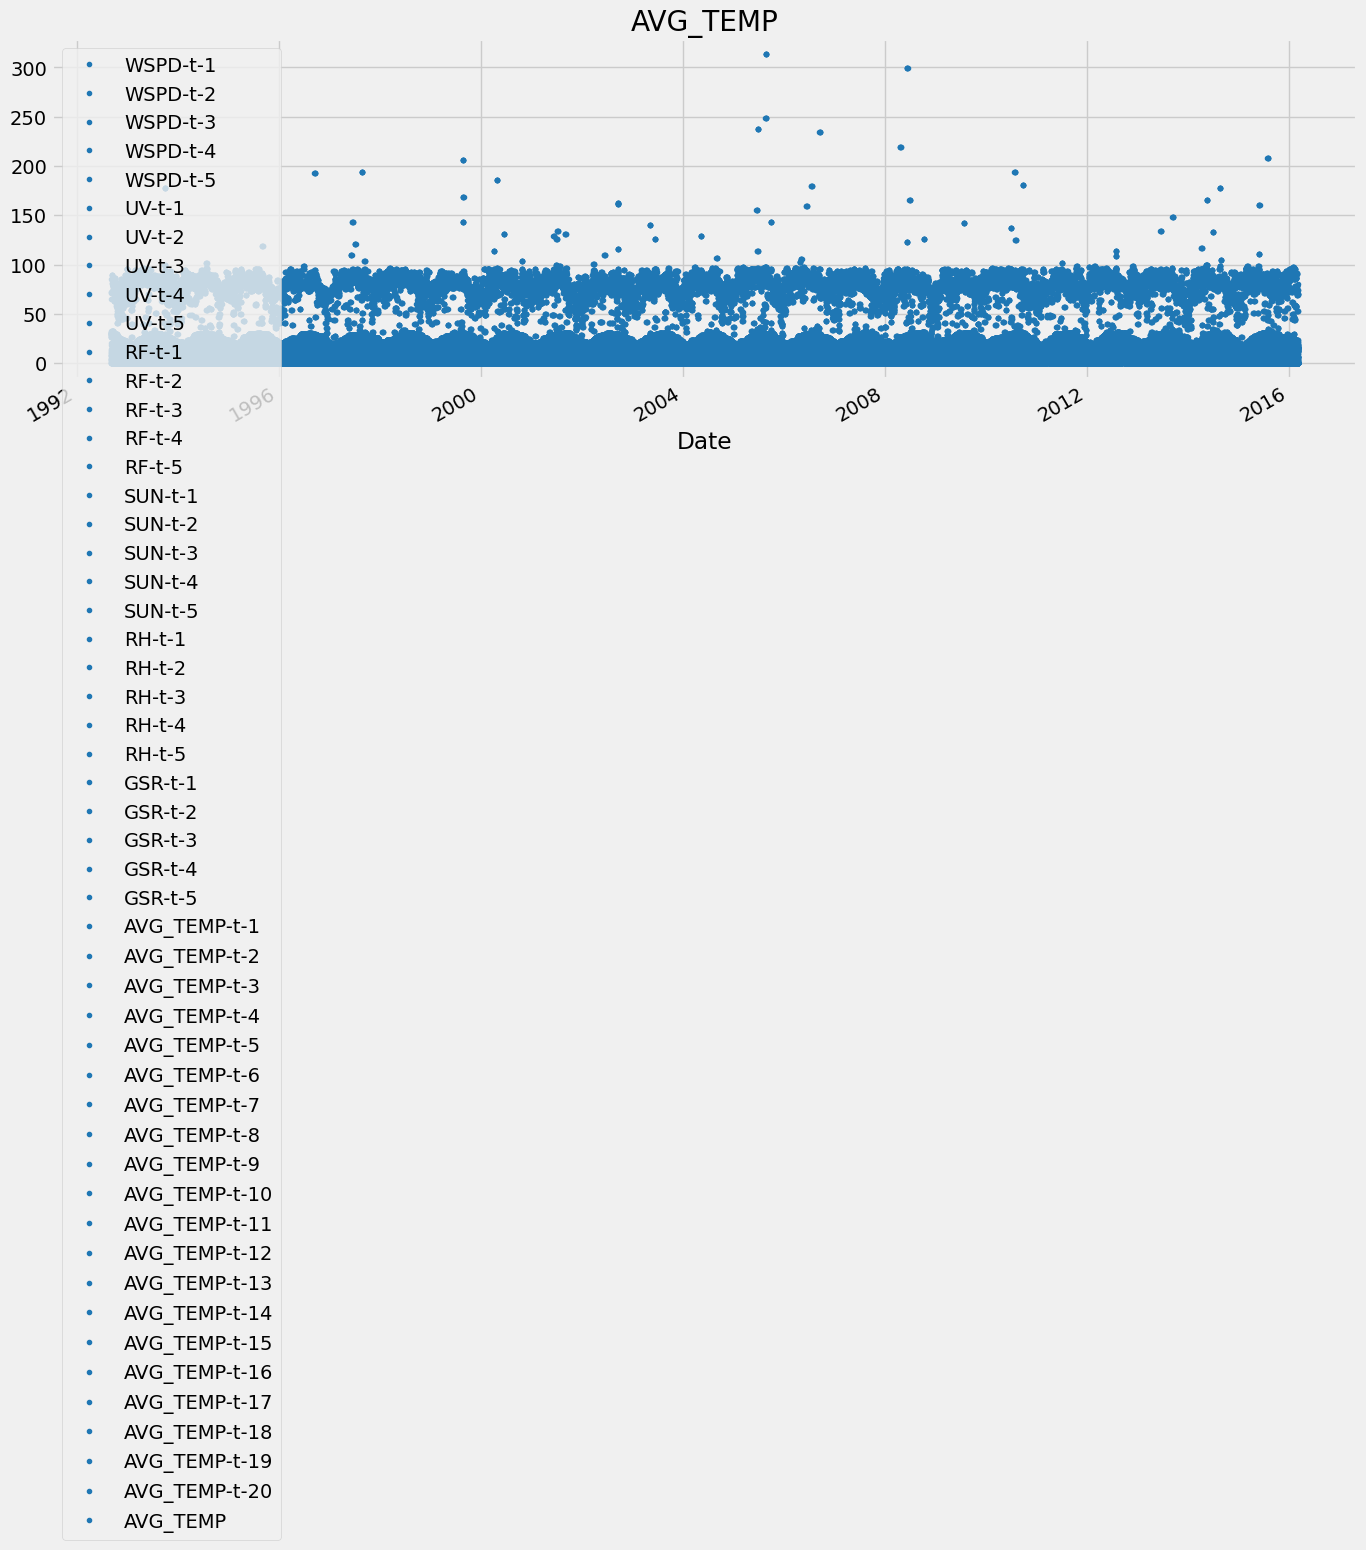

In [6]:
# columns are t-1 ... t-50  Date  AVG_TEMP  GSR  RH  SUN  RF  UV  WSPD
# plot the data with dat in x axis, AVG_TEMP in y axis
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.dates as mdates
# make a function that accept the range of data to plot
import seaborn as sns
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

def plot_data(df:DataFrame, start=None, end=-1, n=100):
    temp = df.copy()
    temp = temp.set_index('Date')
    temp.index = pd.to_datetime(temp.index)
    print(temp)
    
    cols = temp.columns.tolist()
    cols.remove('AVG_TEMP')
    # temp drop other features except AVG_TEMP
    # temp = temp.drop(columns=cols) # drop other features except AVG_TEMP
    
    # if not start:
    #     start = len(temp) - n
    # if end == -1:
    #     end = len(temp)
        
    # print(start, end)
    # temp = temp[start:end]
    
    temp.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='AVG_TEMP')
    
    plt.show()
    return temp

df = plot_data(join_df, n=400)


In [7]:
def create_features(df:DataFrame):
    """
    Create time series features based on time series index.
    """
    
    df = df.copy()
    # df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

print(df)
df = create_features(df)
print(df)

            WSPD-t-1  WSPD-t-2  WSPD-t-3  WSPD-t-4  WSPD-t-5  UV-t-1  UV-t-2  \
Date                                                                           
1992-09-07      10.3      10.9       7.8       7.2       7.8     4.0     4.0   
1992-09-09      11.3      10.3      10.9       7.8       7.2     2.0     4.0   
1992-09-10       5.1      11.3      10.3      10.9       7.8     3.0     2.0   
1992-09-12       4.3       5.1      11.3      10.3      10.9     3.0     3.0   
1992-09-13       9.3       4.3       5.1      11.3      10.3     4.0     3.0   
...              ...       ...       ...       ...       ...     ...     ...   
2016-02-28      10.9      17.0       7.9       6.0       5.1     0.6     1.0   
2016-02-29       4.1      10.9      17.0       7.9       6.0     0.3     0.6   
2016-03-01       9.0       4.1      10.9      17.0       7.9     0.5     0.3   
2016-03-02       6.7       9.0       4.1      10.9      17.0     2.0     0.5   
2016-03-03       3.9       6.7       9.0

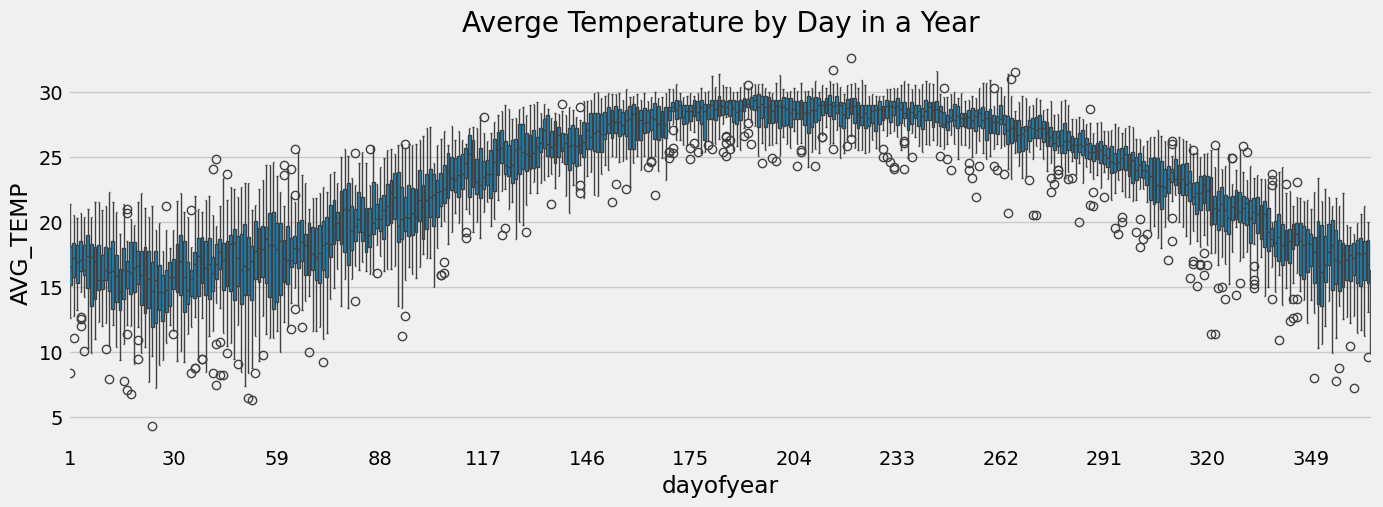

In [8]:
fig, ax = plt.subplots(figsize=(15, 5),)
sns.boxplot(data=df, x='dayofyear', y='AVG_TEMP')
ax.set_title('Averge Temperature by Day in a Year')

# Set the x-axis tick labels
x_ticks = ax.get_xticks()
x_labels = ax.get_xticklabels()
new_x_labels = [label if i % 29 == 0 else '' for i, label in enumerate(x_labels)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(new_x_labels)

plt.show()

In [9]:
print(df)

            WSPD-t-1  WSPD-t-2  WSPD-t-3  WSPD-t-4  WSPD-t-5  UV-t-1  UV-t-2  \
Date                                                                           
1992-09-07      10.3      10.9       7.8       7.2       7.8     4.0     4.0   
1992-09-09      11.3      10.3      10.9       7.8       7.2     2.0     4.0   
1992-09-10       5.1      11.3      10.3      10.9       7.8     3.0     2.0   
1992-09-12       4.3       5.1      11.3      10.3      10.9     3.0     3.0   
1992-09-13       9.3       4.3       5.1      11.3      10.3     4.0     3.0   
...              ...       ...       ...       ...       ...     ...     ...   
2016-02-28      10.9      17.0       7.9       6.0       5.1     0.6     1.0   
2016-02-29       4.1      10.9      17.0       7.9       6.0     0.3     0.6   
2016-03-01       9.0       4.1      10.9      17.0       7.9     0.5     0.3   
2016-03-02       6.7       9.0       4.1      10.9      17.0     2.0     0.5   
2016-03-03       3.9       6.7       9.0

In [10]:
from sklearn.model_selection import train_test_split

x_df = df.drop(columns=['AVG_TEMP'])
y_df = df['AVG_TEMP']

x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=0.3, random_state=0)

In [11]:
x_train

,WSPD-t-1,WSPD-t-2,WSPD-t-3,WSPD-t-4,WSPD-t-5,UV-t-1,UV-t-2,UV-t-3,UV-t-4,UV-t-5,...,AVG_TEMP-t-18,AVG_TEMP-t-19,AVG_TEMP-t-20,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,,,,,,,,,,,,,
2012-02-09,10.5,10.5,8.1,10.1,8.8,0.4,0.6,0.4,0.5,2.0,...,15.7,16.8,19.4,3,1,2,2012,40,9,6
2008-07-05,5.5,7.0,8.3,8.5,3.3,5.0,6.0,4.0,6.0,6.0,...,24.9,26.3,26.6,5,3,7,2008,187,5,27
1994-08-25,4.4,5.0,5.0,3.8,4.7,4.0,5.0,0.7,4.0,3.0,...,26.8,26.3,25.4,3,3,8,1994,237,25,34
2004-05-03,9.7,4.6,5.9,12.4,15.6,4.0,4.0,3.0,4.0,5.0,...,20.4,21.9,25.0,0,2,5,2004,124,3,19
2002-05-18,8.0,3.9,6.2,12.0,13.6,4.0,6.0,3.0,3.0,3.0,...,26.4,25.5,24.0,5,2,5,2002,138,18,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008-03-08,11.6,10.0,14.7,11.1,5.7,0.9,1.0,2.0,4.0,5.0,...,14.6,15.6,15.0,5,1,3,2008,68,8,10
2003-06-27,14.3,10.1,8.5,7.0,9.5,1.0,3.0,6.0,7.0,7.0,...,27.0,26.8,27.3,4,2,6,2003,178,27,26
1998-09-17,16.4,13.0,11.6,10.0,5.1,3.0,2.0,3.0,2.0,4.0,...,29.7,29.5,29.5,3,3,9,1998,260,17,38


In [31]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

reg = xgb.XGBRegressor(base_score=0.5, 
                       booster='gbtree',    
                     # n_estimators=1000,
                     # early_stopping_rounds=50,
                     objective='reg:squarederror',
                     # max_depth=3,
                     # learning_rate=0.01, 
                     tree_method = "hist", 
                     device = "cuda")

# set up our search grid
param_grid = {"max_depth": list(range(3, 5, 1)), # 4
              "n_estimators": list(range(700, 1000, 100)), # 900
              "learning_rate": [0.015, 0.02, 0.025], # 0.02
              "min_child_weight": [5, 7, 9], # 5
              }

search = GridSearchCV(reg, param_grid, cv=5, verbose=100).fit(x_train, y_train)

print("The best hyperparameters are ",search.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV 1/5; 1/54] START learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700
[CV 1/5; 1/54] END learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700;, score=0.922 total time=   1.4s
[CV 2/5; 1/54] START learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700
[CV 2/5; 1/54] END learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700;, score=0.913 total time=   1.6s
[CV 3/5; 1/54] START learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700
[CV 3/5; 1/54] END learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700;, score=0.922 total time=   1.4s
[CV 4/5; 1/54] START learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700
[CV 4/5; 1/54] END learning_rate=0.015, max_depth=3, min_child_weight=5, n_estimators=700;, score=0.913 total time=   1.3s
[CV 5/5; 1/54] START learning_rate=0.015, max_depth=3, min_child_weight=5, n_e

In [32]:
reg:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = search.best_params_["learning_rate"],
                                   n_estimators = search.best_params_["n_estimators"],
                                   max_depth = search.best_params_["max_depth"],
                                   early_stopping_rounds=50,
                                   objective='reg:squarederror',
                                   base_score=0.5, 
                                   booster='gbtree',)

# reg:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = 0.02,
#                                         n_estimators = 900,
#                                         max_depth = 4,
#                                         early_stopping_rounds=50,
#                                         objective='reg:squarederror',
#                                         base_score=0.5, 
#                                         min_child_weight = 5,
#                                         booster='gbtree',
#                                         tree_method = "hist", 
#                                         device = "cuda")

reg.fit(x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:22.60353	validation_1-rmse:22.83636
[100]	validation_0-rmse:3.33438	validation_1-rmse:3.41634
[200]	validation_0-rmse:1.36270	validation_1-rmse:1.50337
[300]	validation_0-rmse:1.23762	validation_1-rmse:1.42682
[400]	validation_0-rmse:1.19099	validation_1-rmse:1.41843
[500]	validation_0-rmse:1.14311	validation_1-rmse:1.41232
[600]	validation_0-rmse:1.10138	validation_1-rmse:1.40864
[700]	validation_0-rmse:1.06637	validation_1-rmse:1.40684
[800]	validation_0-rmse:1.03306	validation_1-rmse:1.40537
[842]	validation_0-rmse:1.02010	validation_1-rmse:1.40583


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.02, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [18]:
x_test

,WSPD-t-1,WSPD-t-2,WSPD-t-3,WSPD-t-4,WSPD-t-5,UV-t-1,UV-t-2,UV-t-3,UV-t-4,UV-t-5,...,AVG_TEMP-t-18,AVG_TEMP-t-19,AVG_TEMP-t-20,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-04,12.4,9.0,4.2,6.3,11.0,1.0,1.0,2.0,3.0,2.0,...,23.8,23.6,24.0,3,4,11,2004,309,4,45
2005-10-07,9.6,4.3,5.5,5.9,5.2,2.0,3.0,3.0,3.0,3.0,...,28.6,27.8,27.0,4,4,10,2005,280,7,40
2006-01-17,8.1,7.6,7.8,3.2,9.3,2.0,2.0,3.0,3.0,3.0,...,17.8,18.5,16.1,1,1,1,2006,17,17,3
1994-06-08,19.7,12.2,6.8,10.3,12.5,5.0,3.0,0.4,3.0,5.0,...,28.2,27.8,29.1,2,2,6,1994,159,8,23
1998-04-24,14.8,13.0,14.1,8.5,5.3,2.0,2.0,5.0,3.0,2.0,...,22.2,23.5,23.2,4,2,4,1998,114,24,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-02-05,6.7,6.4,8.5,8.2,11.9,2.0,3.0,2.0,2.0,3.0,...,14.1,11.4,10.6,5,1,2,2011,36,5,5
2006-02-17,3.0,6.6,10.1,11.9,13.4,3.0,1.0,2.0,2.0,3.0,...,19.4,17.6,14.6,4,1,2,2006,48,17,7
1999-03-28,4.8,6.0,9.2,16.6,9.8,0.8,3.0,4.0,2.0,5.0,...,18.9,23.1,22.2,6,1,3,1999,87,28,12


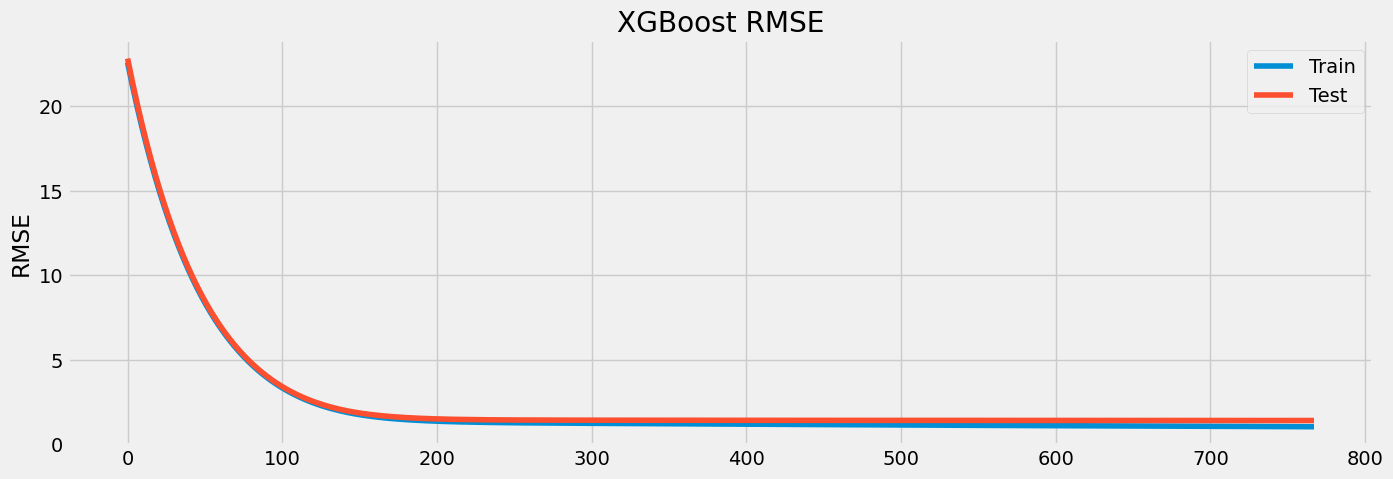

In [19]:
# plot the loss
results = reg.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Test')
ax.legend()
plt.ylabel('RMSE')
plt.title('XGBoost RMSE')
plt.show()

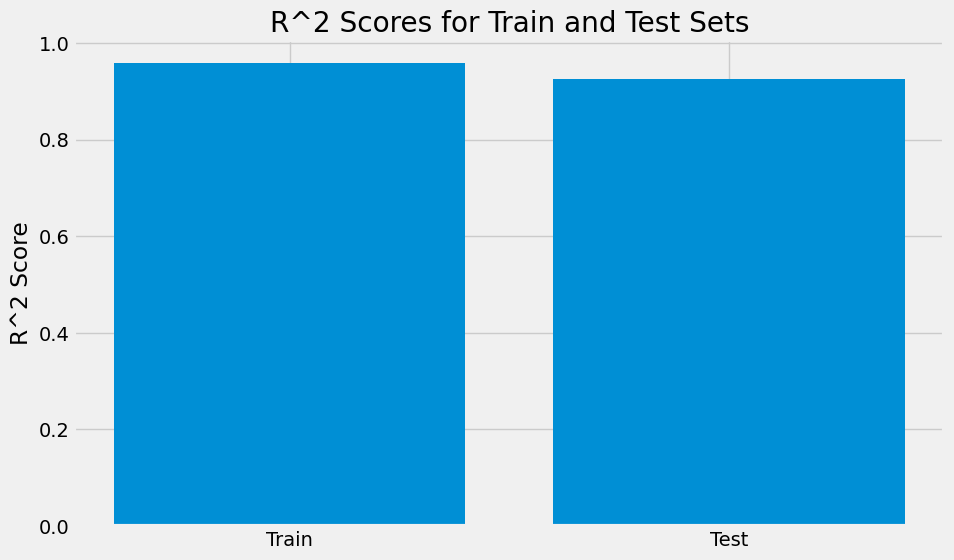

R^2 score for train set:  0.9578742289316802
R^2 score for test set:  0.9253326256434967


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Predict the values
y_train_pred = reg.predict(x_train)
y_test_pred = reg.predict(x_test)

# Calculate R^2 scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Plot R^2 scores
plt.figure(figsize=(10, 6))
plt.bar(['Train', 'Test'], [r2_train, r2_test])
plt.title('R^2 Scores for Train and Test Sets')
plt.ylabel('R^2 Score')
plt.show()

print("R^2 score for train set: ", r2_train)
print("R^2 score for test set: ", r2_test)

In [22]:
y_test

Date
2004-11-04    22.2
2005-10-07    27.8
2006-01-17    18.5
1994-06-08    26.0
1998-04-24    27.2
              ... 
2011-02-05    16.8
2006-02-17    16.5
1999-03-28    19.2
1999-06-14    29.2
2010-05-12    23.6
Name: AVG_TEMP, Length: 2307, dtype: float64

In [23]:
y_test_pred

array([23.46039 , 27.32461 , 18.779024, ..., 24.283829, 28.88351 ,
       23.295048], dtype=float32)

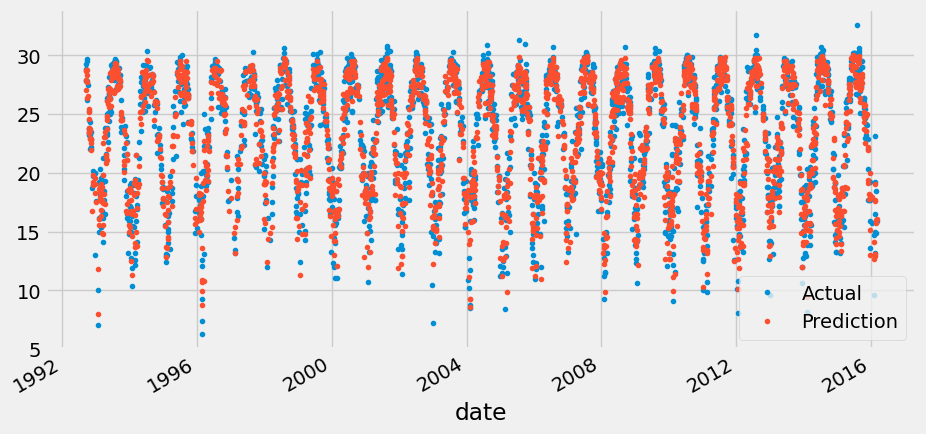

In [29]:
def plot_predictions(testing_dates, y_test, prediction):
  df_test = pd.DataFrame({"date": testing_dates, "actual": y_test, "prediction": prediction })
  figure, ax = plt.subplots(figsize=(10, 5))
  # ax.set_xbound(lower='01-01-2016', upper='02-01-2016')
  df_test.plot(ax=ax, label="Actual", x="date", y="actual", style=".")
  df_test.plot(ax=ax, label="Prediction", x="date", y="prediction", style=".")
  plt.legend(["Actual", "Prediction"])
  plt.show()

plot_predictions(x_test.index, y_test, y_test_pred)
# plot_predictions(x_test.index[-10:], y_test[-10:], y_test_pred[-10:])

In [ ]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance', figsize=(5, 20))
plt.show()

In [ ]:
from utils.DataPreprocessing import DataPreprocessing

x_train, x_test, y_train, y_test = DataPreprocessing(join_df) # 7:3

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)
print(x_train)

In [ ]:

regressor = xgb.XGBRegressor(eval_metric='rmse')

from sklearn.model_selection import GridSearchCV
# set up our search grid
param_grid = {"max_depth":    [4, 5, 6],
              "n_estimators": [500, 600, 700],
              "learning_rate": [0.01, 0.015]}

# search = GridSearchCV(regressor, param_grid, cv=5, verbose=1).fit(x_train, y_train)

# print("The best hyperparameters are ",search.best_params_)

In [ ]:
# regressor:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = search.best_params_["learning_rate"],
#                            n_estimators  = search.best_params_["n_estimators"],
#                            max_depth     = search.best_params_["max_depth"],
#                            eval_metric='rmsle')

# regressor.fit(x_train, y_train)

# predictions = regressor.predict(x_test)

# import numpy as np
# from sklearn.metrics import mean_squared_error
# RMSLE = mean_squared_error(y_test, predictions)
# print("The score is %.5f" % RMSLE )